In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [2]:
df=pd.read_csv("Iris.csv")
df
df.dtypes

Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

In [3]:
# Bayes’ Theorem
# P(A∣B)=  ( P(B∣A)×P(A) ) / P(B)

In [4]:
X=df.drop(['Species','Id'],axis=1)
y=df['Species']
y
X.dtypes

SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
dtype: object

In [5]:
# from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.4,random_state=0)
# X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.5)
print(len(X_train))
print(len(X_test))
print(y_test.shape)
X_test

90
60
(60,)


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
114,5.8,2.8,5.1,2.4
62,6.0,2.2,4.0,1.0
33,5.5,4.2,1.4,0.2
107,7.3,2.9,6.3,1.8
7,5.0,3.4,1.5,0.2
100,6.3,3.3,6.0,2.5
40,5.0,3.5,1.3,0.3
86,6.7,3.1,4.7,1.5
76,6.8,2.8,4.8,1.4
71,6.1,2.8,4.0,1.3


In [6]:
# from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model

GaussianNB()

In [7]:
model.fit(X_train,y_train)
model

GaussianNB()

In [8]:
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [9]:
type(X_test)
p=pd.DataFrame([[5.1, 3.5, 1.4, 0.2]], columns=['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'])
model.predict(p)

array(['Iris-setosa'], dtype='<U15')

In [10]:
y_pred=model.predict(X_test)
y_pred

array(['Iris-virginica', 'Iris-versicolor', 'Iris-setosa',
       'Iris-virginica', 'Iris-setosa', 'Iris-virginica', 'Iris-setosa',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-setosa',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-setosa', 'Iris-setosa',
       'Iris-virginica', 'Iris-versicolor', 'Iris-setosa', 'Iris-setosa',
       'Iris-virginica', 'Iris-setosa', 'Iris-setosa', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-setosa', 'Iris-virginica',
       'Iris-versicolor', 'Iris-setosa', 'Iris-virginica',
       'Iris-virginica', 'Iris-versicolor', 'Iris-setosa',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-virginica', 'Iris-setosa', 'Iris-virginica', 'Iris-setosa',
       'Iris-setosa', 'Iris-versicolor', 'Iris-virginica',
       'Iris-virginica', 'Iris-versicolor', 'Iris-virginica',
       'Iris-versicolo

In [11]:
# from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
cm

array([[16,  0,  0],
       [ 0, 23,  0],
       [ 0,  4, 17]])

In [12]:
TP = cm[0][0]
FP = cm[1][0] + cm[2][0]
FN = cm[0][1] + cm[0][2]
TN = cm[1][1] + cm[1][2] + cm[2][1] + cm[2][2]

print("TP:", TP)
print("FP:", FP)
print("FN:", FN)
print("TN:", TN)

TP: 16
FP: 0
FN: 0
TN: 44


In [13]:
Accuracy = (TP + TN) / (TP + TN + FP + FN)
Error_rate = 1 - Accuracy
Precision = TP / (TP + FP)
Recall = TP / (TP + FN)

print("Accuracy:", Accuracy)
print("Error Rate:", Error_rate)
print("Precision:", Precision)
print("Recall:", Recall)

Accuracy: 1.0
Error Rate: 0.0
Precision: 1.0
Recall: 1.0


In [14]:
# from sklearn.metrics import accuracy_score, precision_score, recall_score
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='macro'))
print("Recall:", recall_score(y_test, y_pred, average='macro'))

Accuracy: 0.9333333333333333
Precision: 0.9506172839506174
Recall: 0.9365079365079364


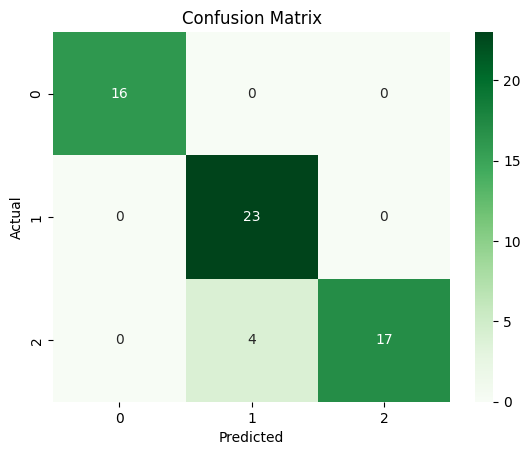

In [15]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Note: In multi-class classification, off-diagonal values represent misclassifications.
# For a given class, a misclassified instance acts as a False Negative (FN) for the actual class 
# and a False Positive (FP) for the predicted class. 
# Therefore, FP and FN are defined per class, not per cell.

In [ ]:
# When evaluating one class at a time (one-vs-rest), 
# the confusion matrix metrics such as TP, FP, FN and TN are calculated separately for each class.
# Let's consider the scenario where the model processed 30 images:

# Predicted Cat		Predicted Dog	Predicted	 Horse
# Actual Cat			8				1			1
# Actual Dog			2				10			0
# Actual Horse			0				2			8
# In this scenario:

# Cats: 8 were correctly identified, 1 was misidentified as a dog and 1 was misidentified as a horse.
# Dogs: 10 were correctly identified, 2 were misidentified as cats.
# Horses: 8 were correctly identified, 2 were misidentified as dogs.

# To calculate true negatives, we need to know the total number of images that were NOT cats, dogs or horses. 
# Let's assume there were 10 such images and the model correctly classified all of them as "not cat," "not dog," and "not horse." Therefore:
# True Negative (TN) Counts: 10 for each class as the model correctly identified each non-cat/dog/horse image as not belonging to that class